# LAB 2. APPLICATIONS OF EIGENVECTORS

### Created by: Tetiana Mazko

Git Hub: https://github.com/tmazko/Python_Labs_Applied_LA/tree/master/Lab_2

In [1]:
import numpy as np
from matplotlib.image import imread
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## Task 1: Computing Eigenvalues and Eigenvectors of a Matrix

In [10]:
def compute_eigenvalues_and_vectors(A):
    eigenvalues, eigenvectors = np.linalg.eig(A)
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)

    return eigenvalues, eigenvectors

In [11]:
def verification(A, eigenvalues, eigenvectors):
    print("Eigenvalues:")
    print(eigenvalues)
    print("\nEigenvectors:")
    print(eigenvectors)

    print("\nVerification A·v = λ·v for each λ/v:")
    for i in range(len(eigenvalues)):

        v = eigenvectors[:, i]
        lamb = eigenvalues[i]
        left = A @ v
        right = lamb * v

        print(f"\nEigenvalue λ = {lamb}")
        print("A·v =", left)
        print("λ·v =", right)
        print("Difference =", left - right)

In [14]:
A = np.array([
    [4, -2],
    [1, 1]
])

eigenvalues, eigenvectors = compute_eigenvalues_and_vectors(A)
eigenvalues, eigenvectors


(array([3., 2.]),
 array([[0.89442719, 0.70710678],
        [0.4472136 , 0.70710678]]))

In [15]:
verification(A, eigenvalues, eigenvectors)

Eigenvalues:
[3. 2.]

Eigenvectors:
[[0.89442719 0.70710678]
 [0.4472136  0.70710678]]

Verification A·v = λ·v for each λ/v:

Eigenvalue λ = 3.0
A·v = [2.68328157 1.34164079]
λ·v = [2.68328157 1.34164079]
Difference = [0. 0.]

Eigenvalue λ = 2.0
A·v = [1.41421356 1.41421356]
λ·v = [1.41421356 1.41421356]
Difference = [0. 0.]


## Task 2: Implementation of Image Dimensionality Reduction Using PCA

#### 1. Image Loading and Initial Dimensions Analysis

In [16]:
img_rows = imread('barcelona_sobor1.jpg')

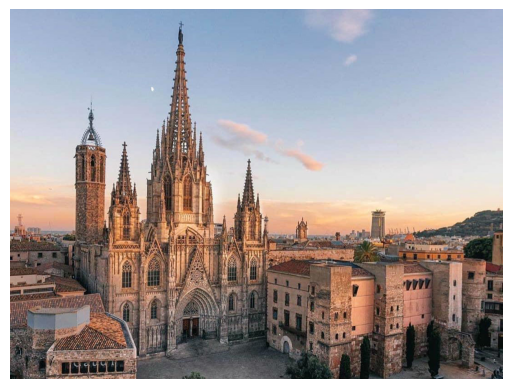

In [5]:
plt.imshow(img_rows)
plt.axis('off')
plt.show()

In [6]:
img_rows.shape

(810, 1080, 3)

#### 2. Grayscale Conversion and Data Normalization

In [3]:

img_sum=img_rows.sum(axis=2)
img_sum.shape

(810, 1080)

In [4]:
img_bw=img_sum/img_sum.max()
img_bw.max()

np.float64(1.0)

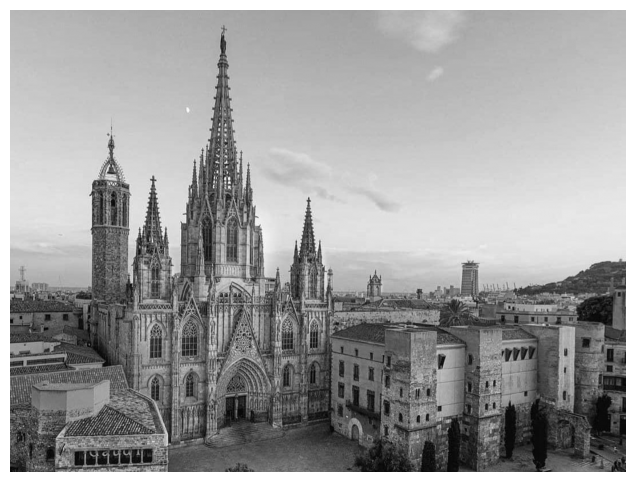

In [9]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.imshow(img_bw, cmap='gray')
plt.axis('off')
plt.show()

#### 3. PCA Implementation and Cumulative Variance Analysis (95% Threshold)

In [5]:
pca = PCA()
pca.fit(img_bw)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [6]:
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
d

np.int64(40)

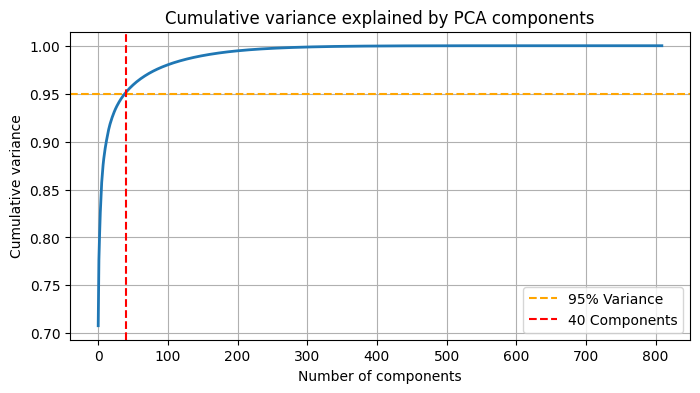

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(cumsum, linewidth=2)
plt.axhline(y=0.95, linestyle='--', label='95% Variance', color='orange')
plt.axvline(x=d, linestyle='--', label=f'{d} Components', color='r')
plt.xlabel('Number of components')
plt.ylabel('Cumulative variance')
plt.title('Cumulative variance explained by PCA components')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
pca_95 = PCA(n_components=d)

img_transformed = pca_95.fit_transform(img_bw)

img_reconstructed = pca_95.inverse_transform(img_transformed)

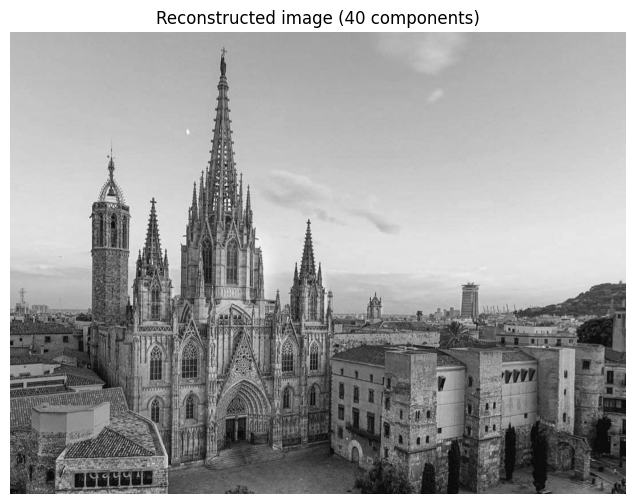

In [46]:
plt.figure(figsize=(10, 6), facecolor='white')
plt.imshow(img_reconstructed, cmap='gray')
plt.title(f'Reconstructed image'
          f' ({d} components)')
plt.axis('off')
plt.show()

#### Conclusion:
PCA allowed us to reconstruct the image using a limited number of components while preserving the overall geometry and main objects. The result confirms that while major features are retained, the fine details responsible for image sharpness are lost in the discarded 5% of variance.

#### 4. Quality Comparison across Components

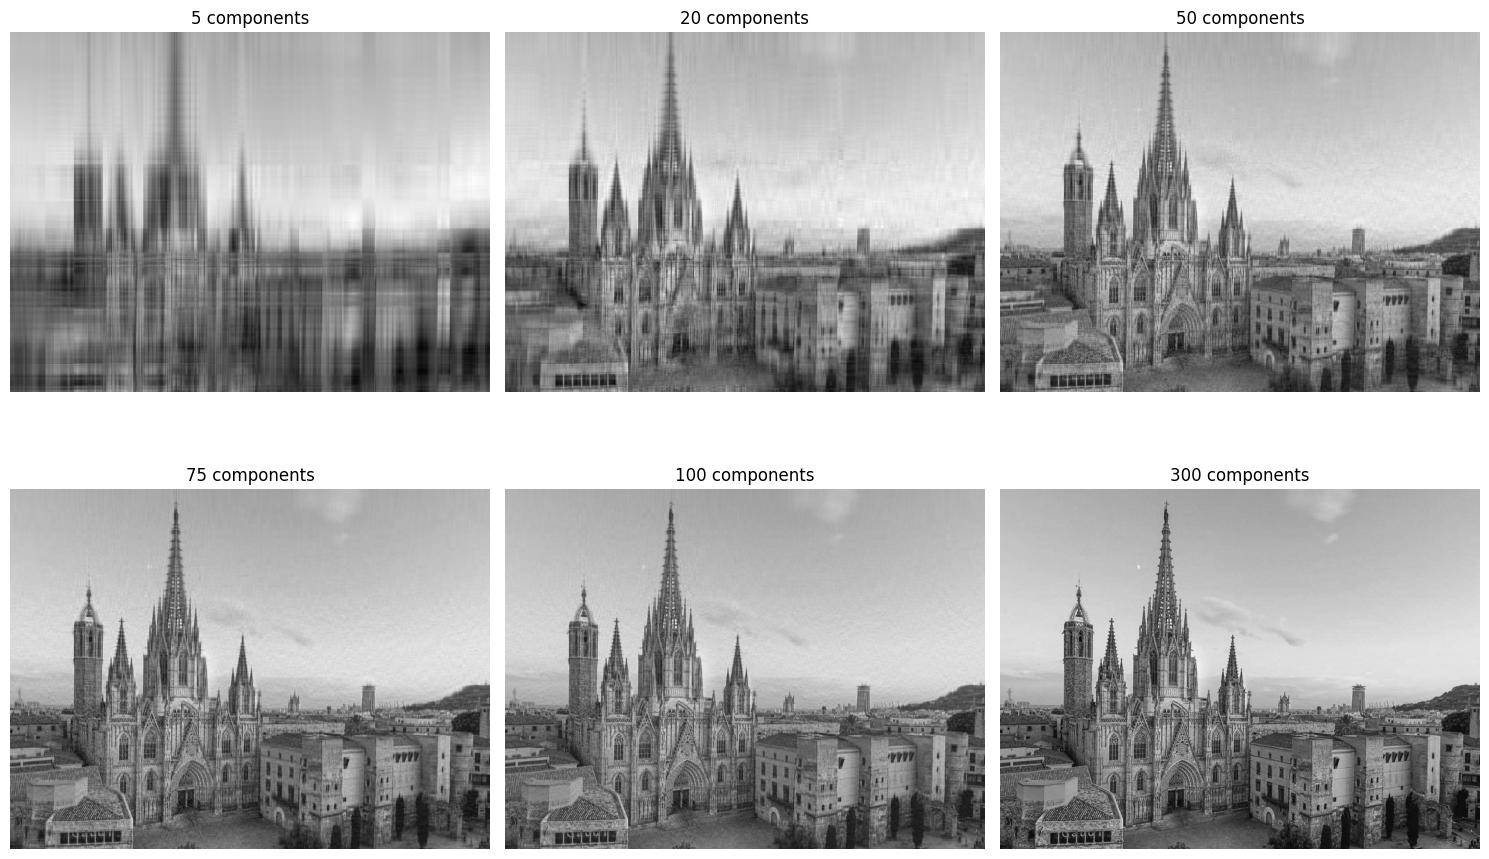

In [9]:
components_list = [5, 20, 50, 75, 100, 300]

plt.figure(figsize=(15, 10), facecolor='white')

for i, n_comp in enumerate(components_list):
    pca_temp = PCA(n_components=n_comp)

    img_transformed = pca_temp.fit_transform(img_bw)
    img_reconstructed = pca_temp.inverse_transform(img_transformed)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title(f'{n_comp} components')
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Conclusion:
Using fewer components results in a blurry image because we only retain the main outlines and lose fine details(low-frequency data).
However, increasing the number of components captures more variance and high-frequency data, which makes the reconstructed image significantly sharper.

## Task 3: Using Diagonalization, Eigenvalues and Eigenvectors in Cryptography

In [18]:
def encrypt_message(message, key_matrix):
    message_vector = np.array([ord(char) for char in message])
    eigenvalues, eigenvectors = np.linalg.eig(key_matrix)
    diagonalized_key_matrix = np.dot(np.dot(eigenvectors, np.diag(eigenvalues)), np.linalg.inv(eigenvectors))
    encrypted_vector = np.dot(diagonalized_key_matrix, message_vector)
    return encrypted_vector

In [19]:
def decrypte_message(encrypted_vector, key_matrix):
    eigenvalues, eigenvectors = np.linalg.eig(key_matrix)
    diagonalized_key_matrix = np.dot(np.dot(eigenvectors, np.diag(eigenvalues)), np.linalg.inv(eigenvectors))
    decrypted_vector=np.dot(np.linalg.inv(diagonalized_key_matrix), encrypted_vector)
    decrypted_vector = np.real(decrypted_vector)
    return "".join(np.array([chr(int(np.round(code))) for code in decrypted_vector]))

In [24]:
message= "I want to go on vacation!"
key_matrix=np.random.randint(0, 256, (len(message), len(message)))

In [25]:
encrypted_vector = encrypt_message(message, key_matrix)
encrypted_vector

array([290787.+1.66494036e-10j, 337557.+1.50987259e-10j,
       267612.+1.83528380e-10j, 265886.+1.28727694e-10j,
       319676.+1.98741767e-10j, 232346.+1.23621457e-10j,
       261048.+1.59602016e-10j, 298561.+1.63978037e-10j,
       324647.+1.61151457e-10j, 239093.+1.31052148e-10j,
       302310.+1.71219283e-10j, 268160.+1.48189160e-10j,
       259253.+1.48140883e-10j, 248680.+1.95546060e-10j,
       270712.+2.06416538e-10j, 296657.+1.58143877e-10j,
       274709.+1.56620676e-10j, 286373.+1.67966465e-10j,
       243416.+1.37546504e-10j, 292047.+1.60295603e-10j,
       262729.+1.40180658e-10j, 263132.+1.56189012e-10j,
       261439.+1.87250706e-10j, 240918.+1.78132378e-10j,
       287510.+1.20464594e-10j])

In [26]:
decrypted_message=decrypte_message(encrypted_vector, key_matrix )
decrypted_message

'I want to go on vacation!'